In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files
upload = files.upload()

Saving WineQT.csv to WineQT.csv


In [ ]:
df = pd.read_csv('WineQT.csv', header=0)

In [ ]:
df.sample(5)

,Class label,Alcohol,Malic acid
938,6.7,0.46,0.24
246,9.6,0.56,0.31
480,8.6,0.8,0.11
588,9.1,0.66,0.15
735,7.6,0.78,0.0


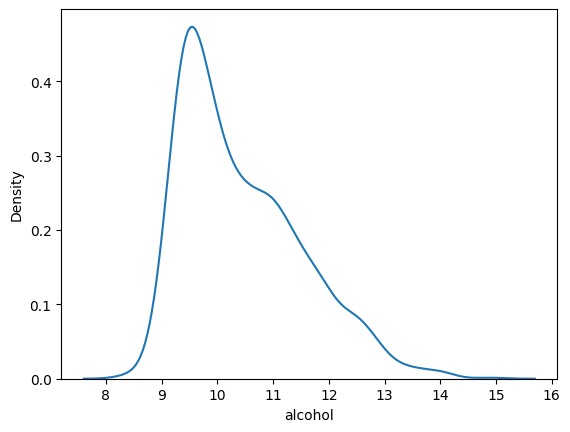

In [ ]:
df['alcohol'] = pd.to_numeric(df['alcohol'], errors='coerce') # Convert to numeric, coercing errors
sns.kdeplot(df['alcohol'])
plt.show() # Add plt.show() to display the plot

<Axes: xlabel='alcohol', ylabel='volatile acidity'>

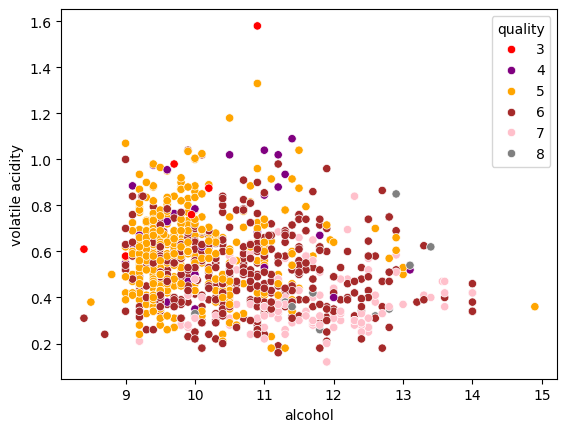

In [ ]:
# Get unique quality values
unique_qualities = df['quality'].unique()

# Create a more comprehensive color dictionary or use a colormap
# For now, let's create a dictionary with some default colors for the missing keys
color_dict = {3:'red', 2:'green', 1:'blue'}
# Add default colors for missing keys
for quality in unique_qualities:
    if quality not in color_dict:
        # Assign a default color (e.g., using a colormap or just adding more colors)
        # For simplicity, let's add some more distinct colors
        if quality == 4:
            color_dict[quality] = 'purple'
        elif quality == 5:
            color_dict[quality] = 'orange'
        elif quality == 6:
            color_dict[quality] = 'brown'
        elif quality == 7:
            color_dict[quality] = 'pink'
        elif quality == 8:
            color_dict[quality] = 'gray'
        else:
             color_dict[quality] = 'black' # Fallback color for any other unexpected values


sns.scatterplot(x=df['alcohol'] , y=df['volatile acidity'] , hue=df['quality'] , palette = color_dict)

# Train test split

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train , X_test , y_train , y_test = train_test_split(df.drop('quality' , axis=1),
                                                       df['quality'],
                                                       test_size=0.2 ,
                                                       random_state=0)

X_train.shape , X_test.shape

((914, 12), (229, 12))

In [ ]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='object')

# **Apply MIn Max Scaller**

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled = pd.DataFrame(X_train_scaled , columns = X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled   , columns = X_test.columns)

In [ ]:
np.round(X_train.describe() , 1)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
count,914.0,914.0,914.0,914.0,914.0,914.0,914.0,914.0,914.0,914.0,914.0,914.0
mean,8.3,0.5,0.3,2.5,0.1,15.4,46.1,1.0,3.3,0.7,10.5,792.6
std,1.8,0.2,0.2,1.3,0.0,10.1,32.4,0.0,0.2,0.2,1.1,467.5
min,4.6,0.1,0.0,0.9,0.0,1.0,6.0,1.0,2.9,0.3,8.4,0.0
25%,7.1,0.4,0.1,1.9,0.1,7.0,21.0,1.0,3.2,0.6,9.5,390.2
50%,7.8,0.5,0.2,2.2,0.1,13.0,37.0,1.0,3.3,0.6,10.2,774.0
75%,9.1,0.6,0.4,2.6,0.1,21.0,62.0,1.0,3.4,0.7,11.2,1202.8
max,15.9,1.3,0.8,15.5,0.6,68.0,289.0,1.0,4.0,2.0,14.9,1597.0


In [ ]:
np.round(X_train_scaled.describe() , 1)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
count,914.0,914.0,914.0,914.0,914.0,914.0,914.0,914.0,914.0,914.0,914.0,914.0
mean,0.3,0.3,0.3,0.1,0.1,0.2,0.1,0.5,0.4,0.2,0.3,0.5
std,0.2,0.1,0.2,0.1,0.1,0.2,0.1,0.1,0.1,0.1,0.2,0.3
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.2,0.2,0.1,0.1,0.1,0.1,0.1,0.4,0.3,0.1,0.2,0.2
50%,0.3,0.3,0.3,0.1,0.1,0.2,0.1,0.5,0.4,0.2,0.3,0.5
75%,0.4,0.4,0.5,0.1,0.1,0.3,0.2,0.6,0.5,0.2,0.4,0.8
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


Text(0.5, 1.0, 'After Scaling')

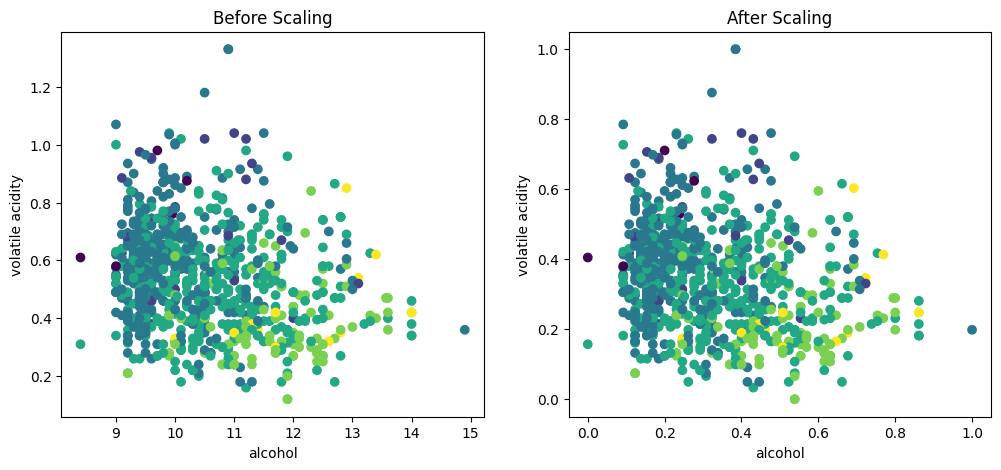

In [ ]:
fig, (ax1 , ax2 ) = plt.subplots(ncols=2 , figsize=(12,5))

ax1.scatter(X_train['alcohol'] , X_train['volatile acidity'] , c = y_train)
ax1.set_xlabel('alcohol')
ax1.set_ylabel('volatile acidity')
ax1.set_title('Before Scaling')

ax2.scatter(X_train_scaled['alcohol'] , X_train_scaled['volatile acidity'] , c = y_train)
ax2.set_xlabel('alcohol')
ax2.set_ylabel('volatile acidity')
ax2.set_title('After Scaling')

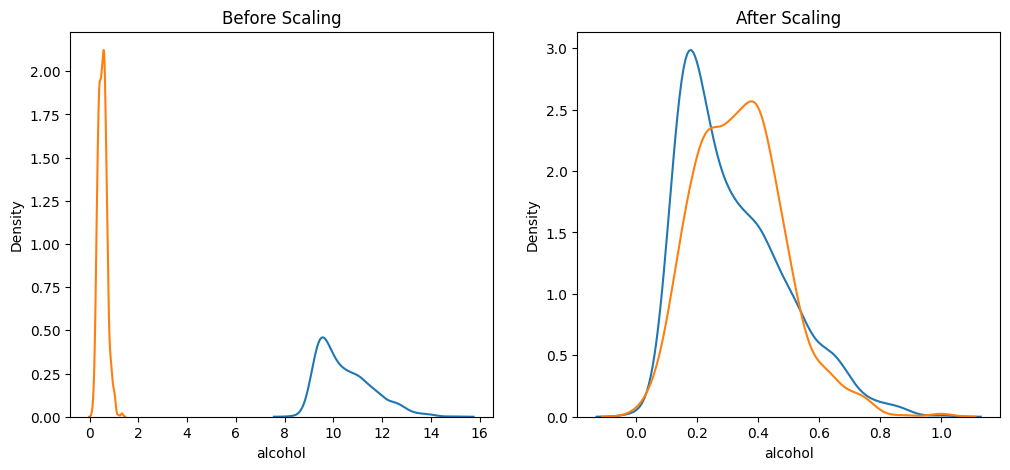

In [ ]:
fig, (ax1 , ax2) = plt.subplots(ncols=2 , figsize=(12,5))

ax1.set_title('Before Scaling')
sns.kdeplot(X_train['alcohol'] , ax=ax1)
sns.kdeplot(X_train['volatile acidity'] , ax=ax1)

ax2.set_title('After Scaling')
sns.kdeplot(X_train_scaled['alcohol'] , ax=ax2)
sns.kdeplot(X_train_scaled['volatile acidity'] , ax=ax2)

plt.show()